In [ ]:
from mmengine.config import Config
from mmdet.apis import init_detector
import os
import custom_angle

TEST_IMG_DIR = os.path.join("/kaggle/input/test-set/test")
TEST_JSON = os.path.join("/kaggle/input/test-set/test/test.json")
WORK_DIR = "/kaggle/working/work_dirs/exp_lr3e-5_loss1_6_6_augTrue/"
os.makedirs(WORK_DIR, exist_ok=True)


CFG_PATH = "/kaggle/input/swin296/kaggle/mask2former_swin-s-p4-w7-224_8xb2-lsj-50e_coco.py"
CKPT_PATH = "/kaggle/input/swin296/kaggle/best_coco_segm_mAP_50_iter_15000.pth"
cfg = Config.fromfile(CFG_PATH)
model = init_detector(cfg, CKPT_PATH, device="cuda")

# RANSAC(Random Sample Consensus) line detection & Hiperparameter Tuning
In questa sezione viene implementato un sistema di ottimizzazione tramite Optuna. L'algoritmo RANSAC viene utilizzato per l'estrazione delle linee. L'implementazione include diverse tecniche di raffinamento:
- Feature extraction: punti estratti tramite l'algoritmo di Canny e Skeletonization.
- Refinement: dopo la fase di RANSAC i parametri $\rho$ e $\theta$ vengono raffinati utilizzando la SVD o i minimi quadrati sugli inliier
- PCA fallback: in caso di fallimento di RANSAC viene utilizzato PCA

RLE(run-length encoding)
- si esegue l'inferenza del modello sul validation set
- le maschere vengono compresse in RLE per minimizzare l'occupazione della memoria RAM

Utilizzando il framework di Optuna con un campionatore TPE(tree-structured parzen estimator) per trovare la combinazione ottimale di iperparametri che massimizza il punteggio LDS. LDS viene calcolato utilizzando il codice fornito per il progetto.

### Iperparametri
- RANSAC Treshold: distanza massima per considerare un punto come inlier
- canny tresholds: sensibilità estrazione dei bordi
- refinement method: svd oppure weighted

### IoU
è stato applicato un filtro che seleziona le predizioni con IoU >= 0.5 

In [ ]:

import os, json, math, time, random
import numpy as np
import cv2
from tqdm import tqdm
from pycocotools import mask as mask_utils
from mmengine.config import Config
from mmdet.apis import init_detector, inference_detector

def compute_LDS(gt_json_path: str, pred_json_path: str) -> float:
    return compute_line_detection_score(gt_json_path, pred_json_path)

def compute_max_iou(pred_rle, gt_annos_img):

    if not gt_annos_img:
        return 0.0
    
    gt_masks_rle = []
    h, w = pred_rle['size']

    for ann in gt_annos_img:
        segm = ann["segmentation"]
        
        
        if isinstance(segm, list):
            
            rles = mask_utils.frPyObjects(segm, h, w)
            
            gt_masks_rle.append(mask_utils.merge(rles))
            
        
        elif isinstance(segm, dict):
            if isinstance(segm['counts'], list):
                
                gt_masks_rle.append(mask_utils.frPyObjects(segm, h, w))
            else:
                
                gt_masks_rle.append(segm)

    if not gt_masks_rle:
        return 0.0
    
    
    try:
        ious = mask_utils.iou([pred_rle], gt_masks_rle, [0] * len(gt_masks_rle))
        return float(np.max(ious)) if ious.size > 0 else 0.0
    except Exception as e:
        
        print(f"Errore IoU: {e}")
        return 0.0




class RANSACLineDetector:
    def __init__(self, 
                 iterations=500,
                 threshold=3.0,
                 min_inliers=5,
                 edge_threshold1=50,
                 edge_threshold2=150,
                 use_skeleton=True,
                 refinement_method='svd'):
        self.iterations = iterations
        self.threshold = threshold
        self.min_inliers = min_inliers
        self.edge_threshold1 = edge_threshold1
        self.edge_threshold2 = edge_threshold2
        self.use_skeleton = use_skeleton
        self.refinement_method = refinement_method
    
    def extract_line_points(self, mask: np.ndarray) -> np.ndarray:
        if mask.dtype != np.uint8:
            mask = mask.astype(np.uint8)
        points_list = []
        if mask.sum() > 0:
            edges = cv2.Canny(mask * 255, self.edge_threshold1, self.edge_threshold2)
            y_edge, x_edge = np.where(edges > 0)
            if len(x_edge) > 0:
                points_list.append(np.column_stack((x_edge, y_edge)))
        if self.use_skeleton and mask.sum() > 100:
            try:
                from skimage.morphology import skeletonize
                skel = skeletonize(mask.astype(bool)).astype(np.uint8)
                y_skel, x_skel = np.where(skel > 0)
                if len(x_skel) > 0:
                    points_list.append(np.column_stack((x_skel, y_skel)))
            except:
                pass
        
        if len(points_list) == 0:
            y_all, x_all = np.where(mask > 0)
            if len(x_all) == 0:
                return np.array([]).reshape(0, 2)
            if len(x_all) > 5000:
                idx = np.random.choice(len(x_all), 5000, replace=False)
                x_all = x_all[idx]
                y_all = y_all[idx]
            return np.column_stack((x_all, y_all))
        
        points = np.vstack(points_list)
        points = np.unique(points, axis=0)
        if len(points) > 3000:
            idx = np.random.choice(len(points), 3000, replace=False)
            points = points[idx]
        return points
    
    def point_to_line_distance(self, point: np.ndarray, rho: float, theta: float) -> float:
        x, y = point
        return abs(x * np.cos(theta) + y * np.sin(theta) - rho)
    
    def fit_line_from_two_points(self, p1: np.ndarray, p2: np.ndarray):
        x1, y1 = p1
        x2, y2 = p2
        dx = x2 - x1
        dy = y2 - y1
        if abs(dx) < 1e-6 and abs(dy) < 1e-6:
            return None
        theta = np.arctan2(-dx, dy)
        rho = x1 * np.cos(theta) + y1 * np.sin(theta)
        if theta < 0:
            theta += np.pi
            rho = -rho
        return rho, theta
    
    def refine_with_svd(self, points: np.ndarray):
        if len(points) < 2:
            return None
        mean = points.mean(axis=0)
        centered = points - mean
        try:
            U, S, Vt = np.linalg.svd(centered, full_matrices=False)
            direction = Vt[0]
        except:
            return None
        normal = np.array([-direction[1], direction[0]])
        normal = normal / (np.linalg.norm(normal) + 1e-12)
        rho = float(mean @ normal)
        theta = float(np.arctan2(normal[1], normal[0]))
        if theta < 0:
            theta += np.pi
            rho = -rho
        return rho, theta
    
    def refine_with_weighted_least_squares(self, points: np.ndarray, initial_rho: float, initial_theta: float):
        if len(points) < 2:
            return initial_rho, initial_theta
        distances = np.array([self.point_to_line_distance(p, initial_rho, initial_theta) for p in points])
        weights = np.exp(-distances**2 / (2 * (self.threshold**2 + 1e-12)))
        sw = weights.sum()
        if sw <= 1e-12:
            return initial_rho, initial_theta
        weights = weights / sw
        mean = np.sum(points * weights[:, None], axis=0)
        centered = points - mean
        try:
            weighted_centered = centered * np.sqrt(weights)[:, None]
            U, S, Vt = np.linalg.svd(weighted_centered, full_matrices=False)
            direction = Vt[0]
        except:
            return initial_rho, initial_theta
        normal = np.array([-direction[1], direction[0]])
        normal = normal / (np.linalg.norm(normal) + 1e-12)
        rho = float(mean @ normal)
        theta = float(np.arctan2(normal[1], normal[0]))
        if theta < 0:
            theta += np.pi
            rho = -rho
        return rho, theta
    
    def ransac_fit(self, points: np.ndarray):
        if len(points) < 2:
            return None
        best_rho, best_theta = None, None
        max_inliers = 0
        best_inliers_mask = None
        n_points = len(points)
        pts = points.astype(np.float32)

        for _ in range(self.iterations):
            idx = np.random.choice(n_points, 2, replace=False)
            p1, p2 = pts[idx]
            res = self.fit_line_from_two_points(p1, p2)
            if res is None:
                continue
            rho, theta = res
            c = np.cos(theta).astype(np.float32)
            s = np.sin(theta).astype(np.float32)
            distances = np.abs(pts[:, 0] * c + pts[:, 1] * s - rho)
            inliers_mask = distances < self.threshold
            num_inliers = int(inliers_mask.sum())
            if num_inliers > max_inliers:
                max_inliers = num_inliers
                best_rho, best_theta = rho, theta
                best_inliers_mask = inliers_mask
                if max_inliers > 0.9 * n_points:
                    break
        
        if max_inliers < self.min_inliers:
            return None

        inlier_points = pts[best_inliers_mask]
        if self.refinement_method == 'svd':
            refined = self.refine_with_svd(inlier_points)
            if refined is not None:
                best_rho, best_theta = refined
        elif self.refinement_method == 'weighted':
            best_rho, best_theta = self.refine_with_weighted_least_squares(inlier_points, best_rho, best_theta)
        return best_rho, best_theta, max_inliers
    
    def detect_line(self, mask: np.ndarray):
        points = self.extract_line_points(mask)
        if len(points) < self.min_inliers:
            return 0.0, 0.0
        result = self.ransac_fit(points)
        if result is None:
            return 0.0, 0.0
        rho, theta, _ = result
        return float(rho), float(theta)


def pca_line_from_points(xs: np.ndarray, ys: np.ndarray):
    if xs.size < 2:
        return 0.0, 0.0
    coords = np.stack([xs, ys], axis=1).astype(np.float32)
    mean = coords.mean(axis=0)
    centered = coords - mean
    cov = centered.T @ centered / max(coords.shape[0] - 1, 1)
    eigvals, eigvecs = np.linalg.eigh(cov)
    direction = eigvecs[:, np.argmax(eigvals)]
    n = np.array([-direction[1], direction[0]], dtype=np.float32)
    n_norm = float(np.linalg.norm(n))
    if n_norm < 1e-8:
        return 0.0, 0.0
    n /= n_norm
    rho = float(mean @ n)
    theta = float(math.atan2(n[1], n[0]))
    return rho, theta

def mask_to_rho_theta_pca(mask_u8: np.ndarray):
    m = (mask_u8 > 0).astype(np.uint8)
    if m.sum() < 10:
        return 0.0, 0.0
    try:
        from skimage.morphology import skeletonize
        skel = skeletonize(m.astype(bool)).astype(np.uint8)
        ys, xs = np.nonzero(skel)
        if xs.size >= 10:
            return pca_line_from_points(xs, ys)
    except:
        pass
    ys, xs = np.nonzero(m)
    if xs.size >= 10:
        return pca_line_from_points(xs, ys)
    return 0.0, 0.0



VAL_IMG_DIR = "/kaggle/input/trainset/train"  
VAL_GT_JSON = "/kaggle/working/fixed_annotations/val_group_split_fixed.json"  

WORK_DIR = "/kaggle/working/work_dirs/ransac_tuning/"
os.makedirs(WORK_DIR, exist_ok=True)



DEVICE = "cuda"


CACHE_PATH = os.path.join(WORK_DIR, "val_inference_cache.npz")
CACHE_META = os.path.join(WORK_DIR, "val_inference_cache_meta.json")

CACHE_JSONL = os.path.join(WORK_DIR, "val_cache_rle.jsonl")

def build_or_load_val_cache_rle(max_images=None, seed=0, score_keep_thr=0.001, topk_keep=120):

    if os.path.exists(CACHE_JSONL):
        print(f"[CACHE] Trovata cache RLE: {CACHE_JSONL}")
        return CACHE_JSONL

    cfg = Config.fromfile(CFG_PATH)
    cfg.work_dir = WORK_DIR
    model = init_detector(cfg, CKPT_PATH, device=DEVICE)

    with open(VAL_GT_JSON, "r") as f:
        val_info = json.load(f)

    images = val_info["images"]
    if max_images is not None:
        rng = np.random.RandomState(seed)
        idx = rng.choice(len(images), size=min(max_images, len(images)), replace=False)
        images = [images[i] for i in idx]

    with open(CACHE_JSONL, "w") as fw:
        for img_info in tqdm(images, desc="Inferenza VAL -> cache RLE"):
            file_name = img_info["file_name"]
            image_id  = int(img_info["id"])
            img_path  = os.path.join(VAL_IMG_DIR, file_name)

            if not os.path.exists(img_path):
                fw.write(json.dumps({"image_id": image_id, "file_name": file_name, "instances": []}) + "\n")
                continue

            result = inference_detector(model, img_path)
            pred = result.pred_instances

            if len(pred) == 0:
                fw.write(json.dumps({"image_id": image_id, "file_name": file_name, "instances": []}) + "\n")
                continue

            scores = pred.scores.detach().cpu().numpy().astype(np.float32)
            bboxes = pred.bboxes.detach().cpu().numpy().astype(np.float32)
            masks  = pred.masks.detach().cpu().numpy().astype(np.uint8)  

            order = np.argsort(scores)[::-1]

            instances = []
            kept = 0
            for i in order:
                s = float(scores[i])
                if s < score_keep_thr:
                    break

                m = masks[i]
                if m.sum() <= 0:
                    continue

                rle = mask_utils.encode(np.asfortranarray(m))
                rle["counts"] = rle["counts"].decode("utf-8")

                x1, y1, x2, y2 = bboxes[i].tolist()
                instances.append({
                    "score": s,
                    "bbox": [float(x1), float(y1), float(x2-x1), float(y2-y1)],
                    "rle": rle
                })
                kept += 1
                if kept >= topk_keep:
                    break

            fw.write(json.dumps({"image_id": image_id, "file_name": file_name, "instances": instances}) + "\n")

    print(f"[CACHE] Salvata cache RLE: {CACHE_JSONL}")
    return CACHE_JSONL



def build_pred_ttpla_from_cache_jsonl(cache_jsonl_path: str,
                                      out_json_path: str,
                                      ransac_params: dict,
                                      score_thr: float,
                                      use_pca_fallback: bool,
                                      gt_json_path: str,
                                      iou_threshold=0.5,
                                      max_masks_per_image=60,
                                      seed=0):
    np.random.seed(seed)
    det = RANSACLineDetector(**ransac_params)

    with open(gt_json_path, "r") as f:
        gt_data = json.load(f)

    from collections import defaultdict
    gt_by_img = defaultdict(list)
    for ann in gt_data["annotations"]:
        gt_by_img[ann["image_id"]].append(ann)

    preds = []
    pred_id = 0

    with open(cache_jsonl_path, "r") as fr:
        for line in fr:
            rec = json.loads(line)
            image_id = int(rec["image_id"])
            inst = rec["instances"]
            
            if not inst: continue

            
            img_gt_annos = gt_by_img.get(image_id, [])

            
            inst = sorted(inst, key=lambda x: x["score"], reverse=True)
            inst = [x for x in inst if x["score"] >= score_thr]

            
            filtered_inst = []
            for obj in inst:
                rle = obj["rle"]
                
                if isinstance(rle["counts"], str):
                    rle["counts"] = rle["counts"].encode("utf-8")
                
                max_iou = compute_max_iou(rle, img_gt_annos)
                
                if max_iou >= iou_threshold:
                    filtered_inst.append(obj)
            
            
            filtered_inst = filtered_inst[:max_masks_per_image]

            for obj in filtered_inst:
                s = float(obj["score"])
                bbox = obj["bbox"]
                rle = obj["rle"]

                mask = mask_utils.decode(rle).astype(np.uint8)
                area = float(mask.sum())
                if area <= 0: continue

                rho, theta = det.detect_line(mask)
                if (rho == 0.0 and theta == 0.0) and use_pca_fallback:
                    rho, theta = mask_to_rho_theta_pca(mask)

                H, W = mask.shape
                preds.append({
                    "image_id": image_id,
                    "category_id": 0,
                    "bbox": bbox,
                    "segmentation": {k: (v.decode("utf-8") if isinstance(v, bytes) else v) 
                                     for k, v in rle.items()},
                    "score": s,
                    "lines": [float(rho), float(theta)],
                    "area": area,
                    "height": int(H),
                    "width": int(W),
                    "id": int(pred_id),
                })
                pred_id += 1

    with open(out_json_path, "w") as f:
        json.dump(preds, f)

    return out_json_path



def try_import_optuna():
    try:
        import optuna
        return optuna
    except Exception as e:
        return None

def tune_ransac(max_trials=40,
                cache_max_images=None,
                eval_fast_subset_images=60,
                seed=0):
    
    cache_full = build_or_load_val_cache_rle(max_images=cache_max_images, seed=seed)

    if eval_fast_subset_images is not None:
        cache_fast = build_or_load_val_cache_rle(max_images=eval_fast_subset_images, seed=seed+1)
    else:
        cache_fast = cache_full

    optuna = try_import_optuna()
    history = []

    def eval_params(params, score_thr, use_pca_fallback, max_masks_per_image, use_fast):
        cache = cache_fast if use_fast else cache_full
        tag = "fast" if use_fast else "full"
        out_json = os.path.join(
            WORK_DIR,
            f"pred_val_{tag}_it{params['iterations']}_thr{params['threshold']}_min{params['min_inliers']}"
            f"_c{params['edge_threshold1']}-{params['edge_threshold2']}_sk{int(params['use_skeleton'])}"
            f"_ref{params['refinement_method']}_s{score_thr:.4f}_pca{int(use_pca_fallback)}.json"
        )
        build_pred_ttpla_from_cache_jsonl(
            cache_jsonl_path=cache,          
            out_json_path=out_json,
            ransac_params=params,
            score_thr=score_thr,
            use_pca_fallback=use_pca_fallback,
            gt_json_path=VAL_GT_JSON,
            iou_threshold=0.5,
            max_masks_per_image=max_masks_per_image,
            seed=seed
        )

        lds = compute_LDS(VAL_GT_JSON, out_json)
        return float(lds), out_json


    if optuna is not None:
        import optuna

        sampler = optuna.samplers.TPESampler(seed=seed)
        study = optuna.create_study(direction="maximize", sampler=sampler)

        def objective(trial):
            # SEARCH SPACE (aggiusta liberamente)
            params = {
                "iterations": trial.suggest_int("iterations", 150, 900, step=50),
                "threshold": trial.suggest_float("threshold", 1.0, 6.0),
                "min_inliers": trial.suggest_int("min_inliers", 3, 30),
                "edge_threshold1": trial.suggest_int("edge_threshold1", 5, 120, step=5),
                "edge_threshold2": trial.suggest_int("edge_threshold2", 30, 250, step=10),
                "use_skeleton": trial.suggest_categorical("use_skeleton", [True, False]),
                "refinement_method": trial.suggest_categorical("refinement_method", ["svd", "weighted"]),
            }
            
            if params["edge_threshold2"] <= params["edge_threshold1"]:
                raise optuna.exceptions.TrialPruned()

            score_thr = trial.suggest_float("score_thr", 0.0005, 0.02, log=True)
            use_pca_fallback = trial.suggest_categorical("use_pca_fallback", [True, False])

            
            max_masks_per_image = trial.suggest_int("max_masks_per_image", 10, 80, step=10)

            
            lds_fast, _ = eval_params(params, score_thr, use_pca_fallback, max_masks_per_image, use_fast=True)

            
            trial.report(lds_fast, step=0)
            if trial.should_prune():
                raise optuna.TrialPruned()

            
            if len(study.trials) >= 5:
                best_so_far = study.best_value
                if lds_fast < best_so_far - 0.30:
                    # troppo distante
                    return lds_fast

            lds_full, out_json = eval_params(params, score_thr, use_pca_fallback, max_masks_per_image, use_fast=False)

            history.append((lds_full, params, score_thr, use_pca_fallback, max_masks_per_image, out_json))
            return lds_full

        print("[TUNING] Optuna disponibile: avvio ottimizzazione...")
        study.optimize(objective, n_trials=max_trials, show_progress_bar=True)

        best = study.best_trial
        print("\n==================== BEST TRIAL ====================")
        print("Best LDS:", best.value)
        print("Params:", best.params)
        print("====================================================")

        # salva risultati
        out_hist = os.path.join(WORK_DIR, "tuning_history.json")
        json.dump(
            [{"LDS":h[0], "ransac_params":h[1], "score_thr":h[2], "use_pca_fallback":h[3],
              "max_masks_per_image":h[4], "pred_json":h[5]} for h in history],
            open(out_hist, "w"),
            indent=2
        )
        print(f"[TUNING] Salvata history: {out_hist}")
        return study

    else:
        print("[TUNING] Optuna NON disponibile: uso Random Search (fallback).")
        rng = np.random.RandomState(seed)

        best_lds = -1e9
        best_cfg = None

        for t in range(max_trials):
            params = {
                "iterations": int(rng.choice(np.arange(150, 901, 50))),
                "threshold": float(rng.uniform(1.0, 6.0)),
                "min_inliers": int(rng.randint(3, 31)),
                "edge_threshold1": int(rng.choice(np.arange(5, 121, 5))),
                "edge_threshold2": int(rng.choice(np.arange(30, 251, 10))),
                "use_skeleton": bool(rng.randint(0, 2)),
                "refinement_method": str(rng.choice(["svd", "weighted"])),
            }
            if params["edge_threshold2"] <= params["edge_threshold1"]:
                continue

            score_thr = float(10 ** rng.uniform(np.log10(5e-4), np.log10(2e-2)))
            use_pca_fallback = bool(rng.randint(0, 2))
            max_masks_per_image = int(rng.choice(np.arange(10, 81, 10)))

            
            lds_fast, _ = eval_params(params, score_thr, use_pca_fallback, max_masks_per_image, use_fast=True)

            
            if best_lds > -1e8 and lds_fast < best_lds - 0.30:
                lds = lds_fast
                out_json = None
            else:
                lds, out_json = eval_params(params, score_thr, use_pca_fallback, max_masks_per_image, use_fast=False)

            history.append((lds, params, score_thr, use_pca_fallback, max_masks_per_image, out_json))

            if lds > best_lds:
                best_lds = lds
                best_cfg = (params, score_thr, use_pca_fallback, max_masks_per_image, out_json)

            print(f"[{t+1:03d}/{max_trials}] LDS={lds:.4f} | best={best_lds:.4f}")

        print("\n==================== BEST (RANDOM) ====================")
        print("Best LDS:", best_lds)
        print("Best cfg:", best_cfg)
        print("=======================================================")

        out_hist = os.path.join(WORK_DIR, "tuning_history.json")
        json.dump(
            [{"LDS":h[0], "ransac_params":h[1], "score_thr":h[2], "use_pca_fallback":h[3],
              "max_masks_per_image":h[4], "pred_json":h[5]} for h in history],
            open(out_hist, "w"),
            indent=2
        )
        print(f"[TUNING] Salvata history: {out_hist}")
        return best_cfg



study_or_best = tune_ransac(
    max_trials=40,
    cache_max_images=None,         
    eval_fast_subset_images=60,    
    seed=0
)


# Inferenza con RANSAC


In [ ]:
import os, json, math
import numpy as np
import cv2
from mmdet.apis import inference_detector
from pycocotools import mask as mask_utils
from tqdm import tqdm
from pycocotools.coco import COCO



class RANSACLineDetector:
    
    def __init__(self, 
                 iterations=1200,
                 threshold=3.0,
                 min_inliers=5,
                 edge_threshold1=50,
                 edge_threshold2=150,
                 use_skeleton=True,
                 refinement_method='svd'):
        self.iterations = iterations
        self.threshold = threshold
        self.min_inliers = min_inliers
        self.edge_threshold1 = edge_threshold1
        self.edge_threshold2 = edge_threshold2
        self.use_skeleton = use_skeleton
        self.refinement_method = refinement_method
    
    def extract_line_points(self, mask: np.ndarray) -> np.ndarray:
        if mask.dtype != np.uint8:
            mask = mask.astype(np.uint8)
        
        points_list = []
        
        
        if mask.sum() > 0:
            edges = cv2.Canny(mask * 255, self.edge_threshold1, self.edge_threshold2)
            y_edge, x_edge = np.where(edges > 0)
            if len(x_edge) > 0:
                points_list.append(np.column_stack((x_edge, y_edge)))
        
        
        if self.use_skeleton and mask.sum() > 100:
            try:
                from skimage.morphology import skeletonize
                skel = skeletonize(mask.astype(bool)).astype(np.uint8)
                y_skel, x_skel = np.where(skel > 0)
                if len(x_skel) > 0:
                    points_list.append(np.column_stack((x_skel, y_skel)))
            except:
                pass
        
        
        if len(points_list) == 0:
            
            y_all, x_all = np.where(mask > 0)
            if len(x_all) == 0:
                return np.array([]).reshape(0, 2)
            
            if len(x_all) > 5000:
                indices = np.random.choice(len(x_all), 5000, replace=False)
                x_all = x_all[indices]
                y_all = y_all[indices]
            return np.column_stack((x_all, y_all))
        
        points = np.vstack(points_list)
        
        
        points = np.unique(points, axis=0)
        
        
        if len(points) > 3000:
            indices = np.random.choice(len(points), 3000, replace=False)
            points = points[indices]
        
        return points
    
    def point_to_line_distance(self, point: np.ndarray, rho: float, theta: float) -> float:
        
        x, y = point
        return abs(x * np.cos(theta) + y * np.sin(theta) - rho)
    
    def fit_line_from_two_points(self, p1: np.ndarray, p2: np.ndarray) -> tuple:
        
        x1, y1 = p1
        x2, y2 = p2
        
        dx = x2 - x1
        dy = y2 - y1
        
        
        if abs(dx) < 1e-6 and abs(dy) < 1e-6:
            return None
        
        
        theta = np.arctan2(-dx, dy)
        
        
        rho = x1 * np.cos(theta) + y1 * np.sin(theta)
        
        
        if theta < 0:
            theta += np.pi
            rho = -rho
        
        return rho, theta
    
    def refine_with_svd(self, points: np.ndarray) -> tuple:
        
        if len(points) < 2:
            return None
        
        
        mean = points.mean(axis=0)
        centered = points - mean
        
        
        try:
            U, S, Vt = np.linalg.svd(centered, full_matrices=False)
            direction = Vt[0]
        except:
            return None
        
        
        normal = np.array([-direction[1], direction[0]])
        normal = normal / np.linalg.norm(normal)
        
        
        rho = float(mean @ normal)
        theta = float(np.arctan2(normal[1], normal[0]))
        
        
        if theta < 0:
            theta += np.pi
            rho = -rho
        
        return rho, theta
    
    def refine_with_weighted_least_squares(self, points: np.ndarray, 
                                           initial_rho: float, 
                                           initial_theta: float) -> tuple:
        
        if len(points) < 2:
            return initial_rho, initial_theta
        
        
        distances = np.array([
            self.point_to_line_distance(p, initial_rho, initial_theta) 
            for p in points
        ])
        
        
        weights = np.exp(-distances**2 / (2 * self.threshold**2))
        weights = weights / weights.sum()
        
        
        mean = np.sum(points * weights[:, np.newaxis], axis=0)
        centered = points - mean
        
        
        try:
            weighted_centered = centered * np.sqrt(weights)[:, np.newaxis]
            U, S, Vt = np.linalg.svd(weighted_centered, full_matrices=False)
            direction = Vt[0]
        except:
            return initial_rho, initial_theta
        
        
        normal = np.array([-direction[1], direction[0]])
        normal = normal / np.linalg.norm(normal)
        
        rho = float(mean @ normal)
        theta = float(np.arctan2(normal[1], normal[0]))
        
        if theta < 0:
            theta += np.pi
            rho = -rho
        
        return rho, theta

    
    
    def ransac_fit(self, points: np.ndarray):
        if len(points) < 2:
            return None
    
        best_rho = None
        best_theta = None
        max_inliers = 0
        best_inliers_mask = None
    
        n_points = len(points)
    
        
        pts = points.astype(np.float32)
    
        for _ in range(self.iterations):
            idx = np.random.choice(n_points, 2, replace=False)
            p1, p2 = pts[idx]
    
            res = self.fit_line_from_two_points(p1, p2)
            if res is None:
                continue
            rho, theta = res
    
            c = np.cos(theta).astype(np.float32)
            s = np.sin(theta).astype(np.float32)
    
            
            distances = np.abs(pts[:, 0] * c + pts[:, 1] * s - rho)
    
            inliers_mask = distances < self.threshold
            num_inliers = int(inliers_mask.sum())
    
            if num_inliers > max_inliers:
                max_inliers = num_inliers
                best_rho, best_theta = rho, theta
                best_inliers_mask = inliers_mask
    
                
                if max_inliers > 0.9 * n_points:
                    break
    
        if max_inliers < self.min_inliers:
            return None
    
        inlier_points = pts[best_inliers_mask]
    
        if self.refinement_method == 'svd':
            refined = self.refine_with_svd(inlier_points)
            if refined is not None:
                best_rho, best_theta = refined
        elif self.refinement_method == 'weighted':
            best_rho, best_theta = self.refine_with_weighted_least_squares(
                inlier_points, best_rho, best_theta
            )
    
        return best_rho, best_theta, max_inliers

    
    def detect_line(self, mask: np.ndarray) -> tuple:
        
        i
        points = self.extract_line_points(mask)
        
        if len(points) < self.min_inliers:
            return 0.0, 0.0
        
        
        result = self.ransac_fit(points)
        
        if result is None:
            return 0.0, 0.0
        
        rho, theta, _ = result
        return float(rho), float(theta)



def pca_line_from_points(xs: np.ndarray, ys: np.ndarray):
   
    if xs.size < 2:
        return 0.0, 0.0
    
    coords = np.stack([xs, ys], axis=1).astype(np.float32)
    mean = coords.mean(axis=0)
    centered = coords - mean
    
    cov = centered.T @ centered / max(coords.shape[0] - 1, 1)
    eigvals, eigvecs = np.linalg.eigh(cov)
    direction = eigvecs[:, np.argmax(eigvals)]
    
    n = np.array([-direction[1], direction[0]], dtype=np.float32)
    n_norm = float(np.linalg.norm(n))
    if n_norm < 1e-8:
        return 0.0, 0.0
    n /= n_norm
    
    rho = float(mean @ n)
    theta = float(math.atan2(n[1], n[0]))
    return rho, theta


def mask_to_rho_theta_pca(mask_u8: np.ndarray):
    
    
    m = (mask_u8 > 0).astype(np.uint8)
    if m.sum() < 10:
        return 0.0, 0.0
    
    
    try:
        from skimage.morphology import skeletonize
        skel = skeletonize(m.astype(bool)).astype(np.uint8)
        ys, xs = np.nonzero(skel)
        if xs.size >= 10:
            return pca_line_from_points(xs, ys)
    except:
        pass
    
    
    ys, xs = np.nonzero(m)
    if xs.size >= 10:
        return pca_line_from_points(xs, ys)
    
    return 0.0, 0.0

def calculate_iou(mask1, mask2):
    intersection = np.logical_and(mask1, mask2).sum()
    if intersection == 0:
        return 0.0
    union = np.logical_or(mask1, mask2).sum()
    return float(intersection / union)







with open(TEST_JSON, "r") as f:
    test_info = json.load(f)
print("STEP 2: Dati test caricati. Inizio inferenza.") 
print(f"\nProcessando {len(test_info['images'])} immagini...")

coco_gt = COCO("/kaggle/working/fixed_annotations/test_fixed.json")




ransac_detector = RANSACLineDetector(
    iterations=1200,           
    threshold=3.0,             
    min_inliers=5,            
    edge_threshold1=50,        
    edge_threshold2=150,       
    use_skeleton=True,         
    refinement_method='svd'    
)

USE_PCA_FALLBACK = True

print("="*60)
print("CONFIGURAZIONE RANSAC:")
print(f"  Iterations: {ransac_detector.iterations}")
print(f"  Threshold: {ransac_detector.threshold} px")
print(f"  Min inliers: {ransac_detector.min_inliers}")
print(f"  PCA fallback: {USE_PCA_FALLBACK}")
print("="*60)



output_predictions_coco = []
output_predictions_ttpla = []
pred_id = 0


FILTERING = True
IOU_THRESHOLD = 0.5 

stats = {
    'total_masks_detected': 0,
    'filtered_by_oracle': 0,
    'ransac_success': 0,
    'pca_fallback': 0,
    'failed': 0
}

print(f"\nProcessando {len(test_info['images'])} immagini...")
SCORE_THR = 0.0001

for img_info in tqdm(test_info["images"]):
    file_name = img_info["file_name"]
    image_id = img_info["id"]
    
    
    gt_ann_ids = coco_gt.getAnnIds(imgIds=[image_id])
    gt_anns = coco_gt.loadAnns(gt_ann_ids)
    gt_masks = [coco_gt.annToMask(ann) for ann in gt_anns]
    
    
    img_path = os.path.join(TEST_IMG_DIR, file_name)
    result = inference_detector(model, img_path)
    
    pred = result.pred_instances
    scores = pred.scores.detach().cpu().numpy()
    bboxes = pred.bboxes.detach().cpu().numpy()
    masks = pred.masks.detach().cpu().numpy()
    
    if scores.size == 0:
        continue
    
    
    candidates = []
    order = np.argsort(scores)[::-1]
    for i in order:
        if scores[i] < SCORE_THR: break
        candidates.append({
            'mask': masks[i],
            'score': scores[i],
            'bbox': bboxes[i]
        })
    
    stats['total_masks_detected'] += len(candidates)
    
    
    selected_for_this_image = []
    
    if FILTERING and len(gt_masks) > 0:
        for gt_m in gt_masks:
            best_iou = 0
            best_cand = None
            
            for cand in candidates:
                iou = calculate_iou(gt_m, cand['mask'])
                if iou > best_iou:
                    best_iou = iou
                    best_cand = cand
            
            
            if best_cand is not None and best_iou >= IOU_THRESHOLD:
                selected_for_this_image.append(best_cand)
    else:
        selected_for_this_image = candidates

    stats['filtered_by_oracle'] += len(selected_for_this_image)

    
    for pred_data in selected_for_this_image:
        mask = pred_data['mask'].astype(np.uint8)
        s = float(pred_data['score'])
        area = float(mask.sum())
        
        x1, y1, x2, y2 = pred_data['bbox'].tolist()
        w, h = (x2 - x1), (y2 - y1)
        H, W = mask.shape
        
        
        rle = mask_utils.encode(np.asfortranarray(mask))
        rle["counts"] = rle["counts"].decode("utf-8")
        
        
        rho, theta = ransac_detector.detect_line(mask)
        
        if (rho == 0.0 and theta == 0.0) and USE_PCA_FALLBACK:
            rho, theta = mask_to_rho_theta_pca(mask)
            if rho != 0.0 or theta != 0.0: stats['pca_fallback'] += 1
            else: stats['failed'] += 1
        elif rho != 0.0 or theta != 0.0:
            stats['ransac_success'] += 1
        else:
            stats['failed'] += 1
        
        
        output_predictions_ttpla.append({
            "image_id": int(image_id),
            "category_id": 0,
            "bbox": [float(x1), float(y1), float(w), float(h)],
            "segmentation": rle,
            "score": float(s),
            "lines": [float(rho), float(theta)],
            "area": float(area),
            "height": int(H),
            "width": int(W),
            "id": int(pred_id),
        })
        pred_id += 1


pred_path_coco = os.path.join(WORK_DIR, "predictions_coco_style.json")
with open(pred_path_coco, "w") as f:
    json.dump(output_predictions_coco, f)

pred_path_ttpla = os.path.join(WORK_DIR, "predictions_ttpla_ransac.json")
with open(pred_path_ttpla, "w") as f:
    json.dump(output_predictions_ttpla, f)

print("\n" + "="*60)
print("RISULTATI:")
print(f"  File COCO: {pred_path_coco}")
print(f"  File TTPLA: {pred_path_ttpla}")
print(f"  Totale predizioni: {len(output_predictions_ttpla)}")
print("\nSTATISTICHE LINEE:")
print(f"  Maschere processate: {stats['total_masks_detected']}")
print(f"  RANSAC successi: {stats['ransac_success']} ({stats['ransac_success']/max(stats['total_masks_detected'],1)*100:.1f}%)")
print(f"  PCA fallback: {stats['pca_fallback']} ({stats['pca_fallback']/max(stats['total_masks_detected'],1)*100:.1f}%)")
print(f"  Fallimenti: {stats['failed']} ({stats['failed']/max(stats['total_masks_detected'],1)*100:.1f}%)")
print("="*60)
print(f"\n COMPLETATO!")

# Analisi qualitativa di alcuni campioni


--- DEBUG COORDINATE POLARI ---
GT: 41 linee, formato: {'polar_coordinates'}
PRED: 14 linee, formato: {'lines'}
✓ Coordinate polari correttamente calcolate!
--------------------------------



C:\Users\angel\AppData\Local\Temp\ipykernel_6640\2616863806.py:423: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


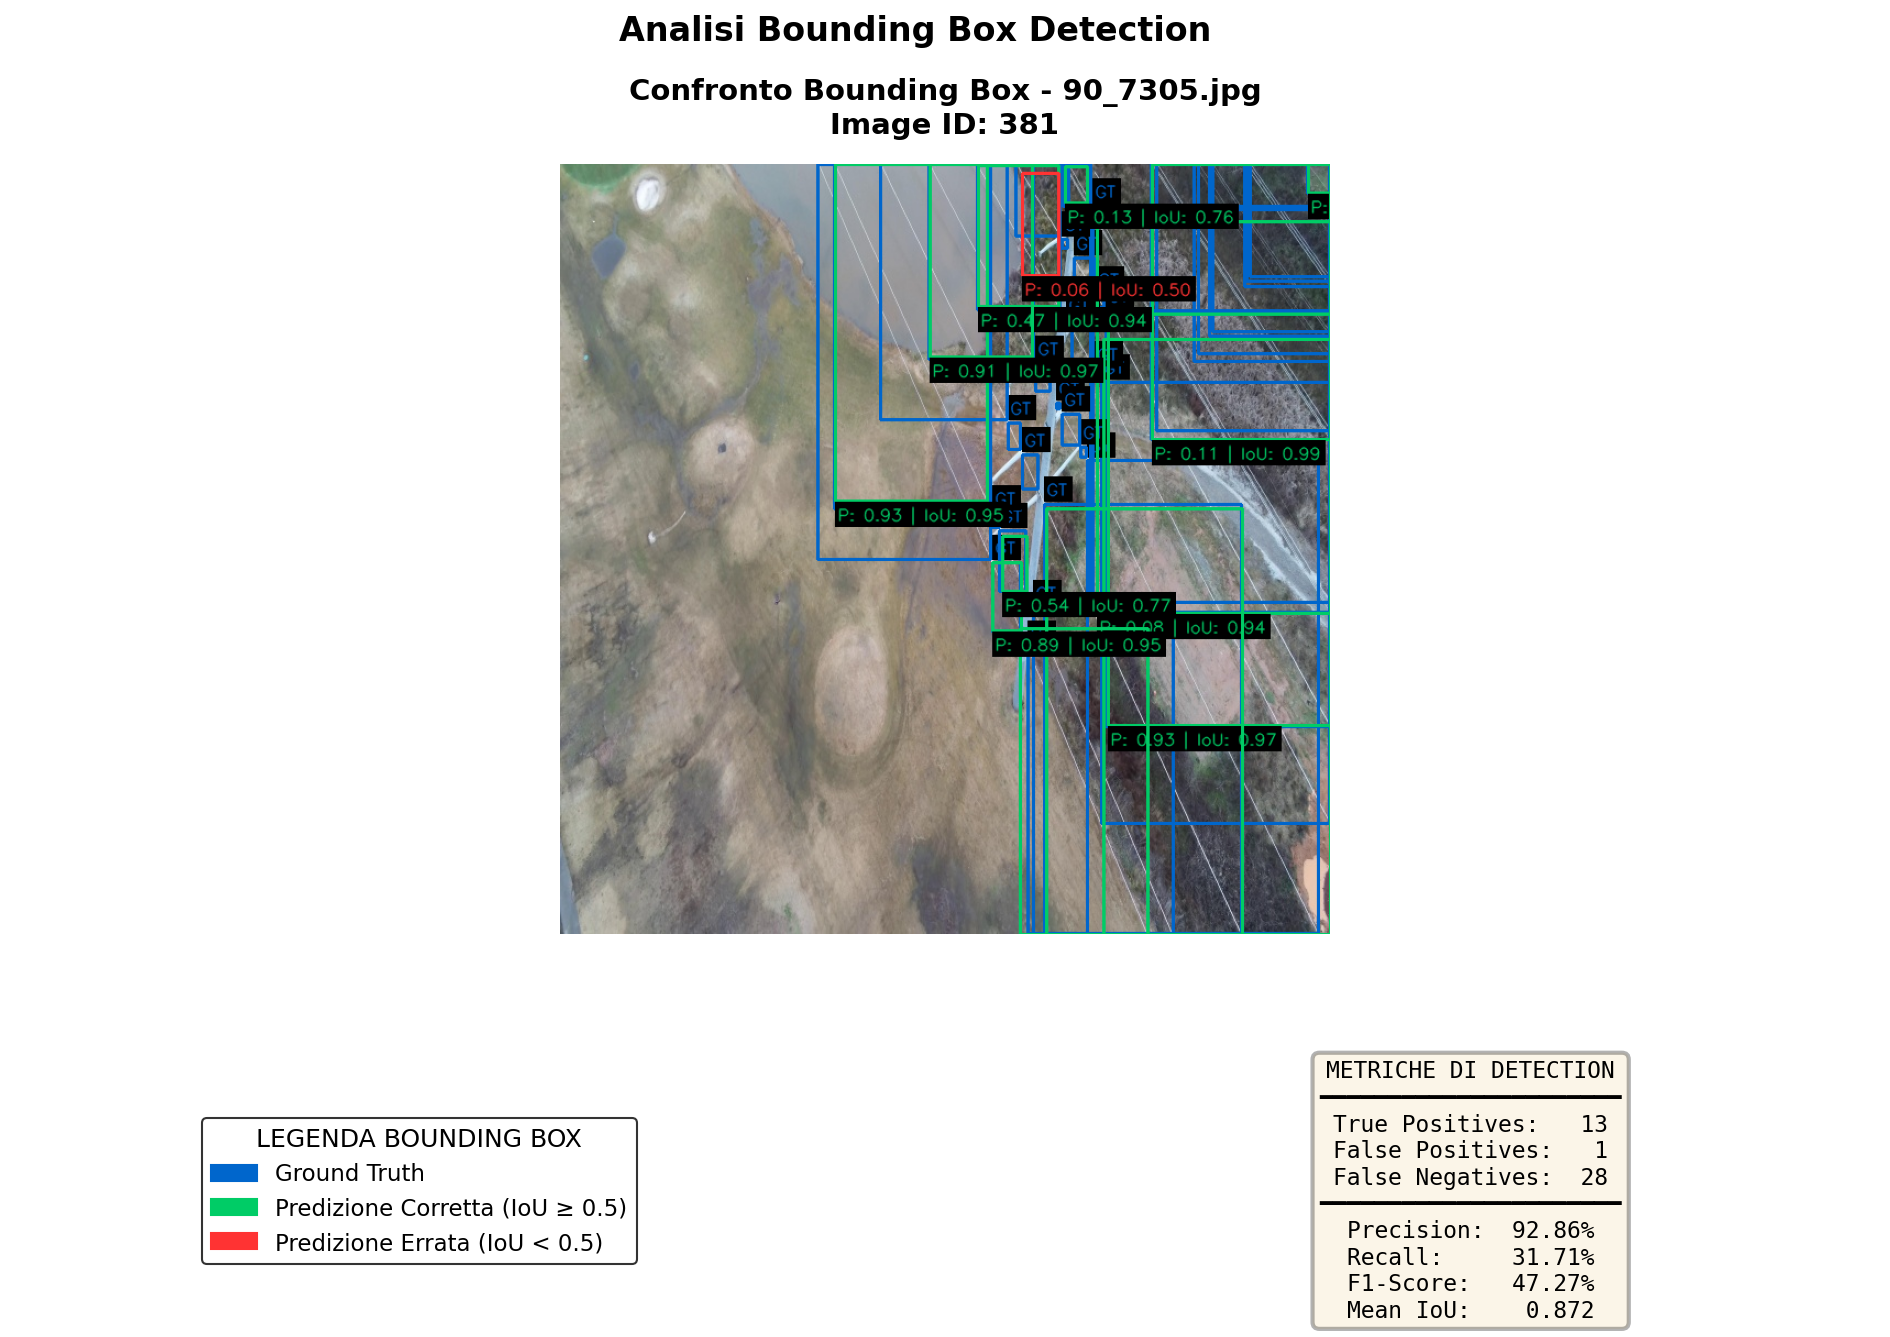

C:\Users\angel\AppData\Local\Temp\ipykernel_6640\2616863806.py:506: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


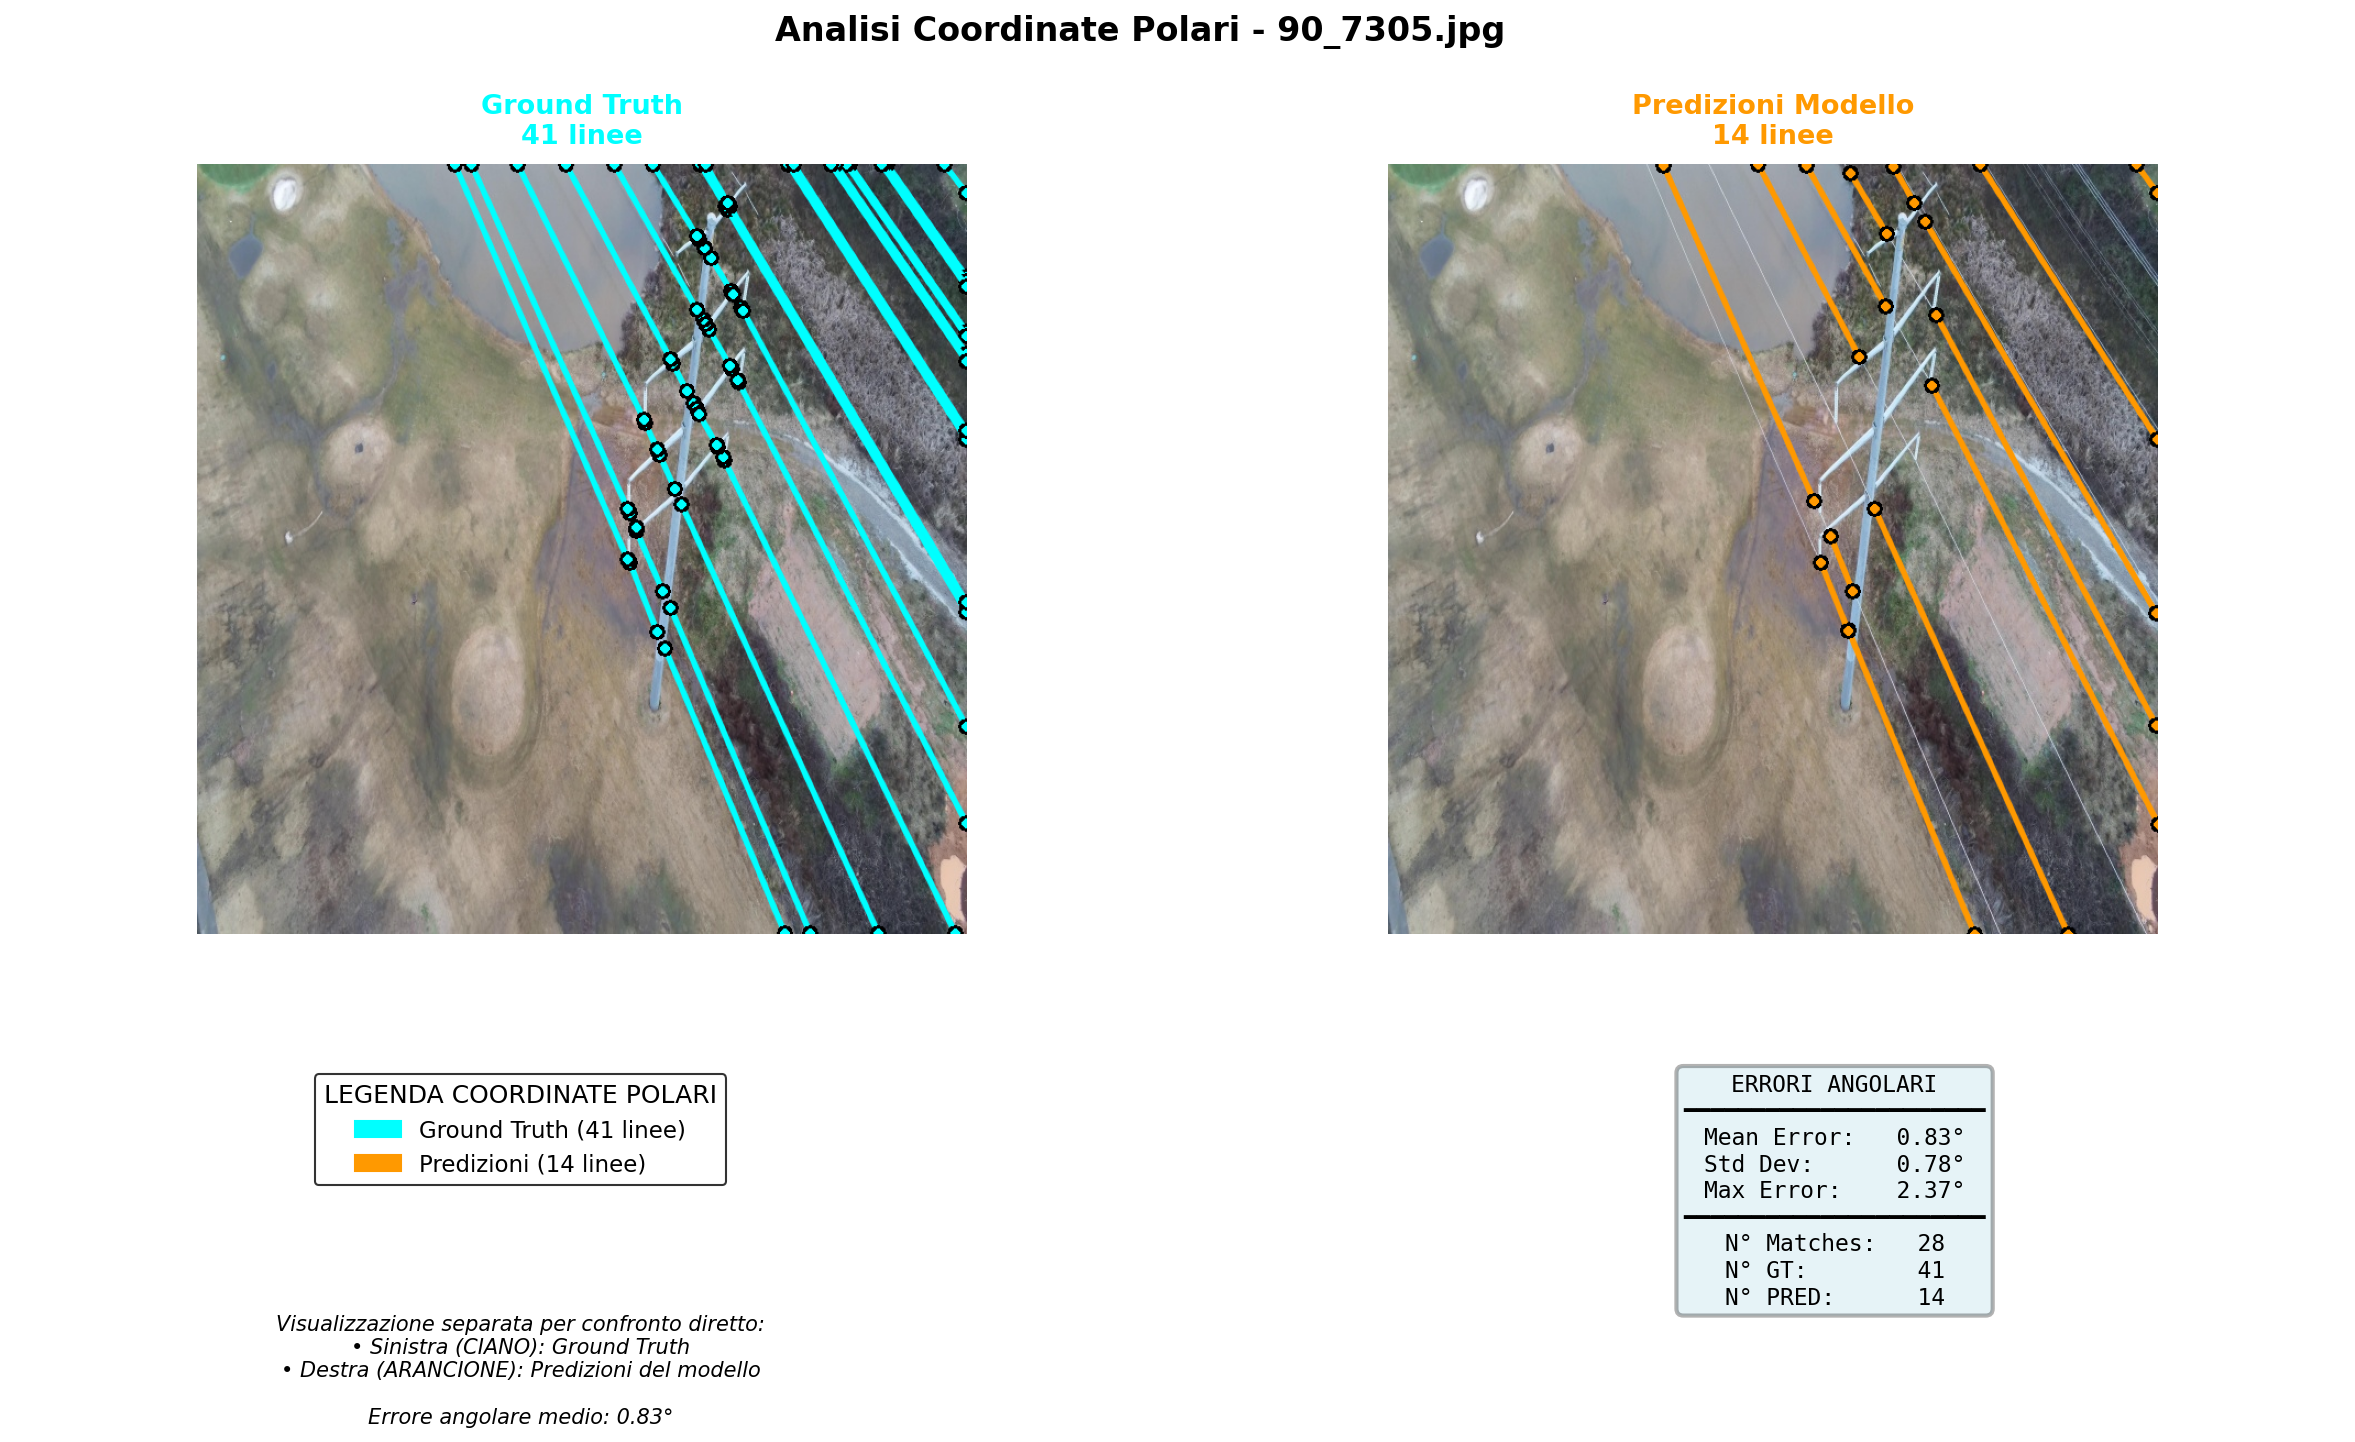


ANALISI COMPLETATA - Image ID: 381
Ground Truth boxes: 41
Predicted boxes: 14
Precision: 92.86%
Recall: 31.71%
F1-Score: 47.27%
Mean IoU: 0.872

COORDINATE POLARI:
Errore angolare medio: 0.83°
Dev. standard: 0.78°
Errore massimo: 2.37°



In [ ]:
import json
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os
from collections import defaultdict
from typing import Dict, List, Tuple, Optional

GT_JSON = "./test.json"
PRED_JSON = "./268986.json"
IMG_DIR = "./test"

COLORS = {
    'gt_bbox': '#0066CC',
    'pred_correct': '#00CC66',
    'pred_wrong': '#FF3333',
    'gt_polar': '#00FFFF',
    'pred_polar': '#FF9900',
    'text_bg': '#000000',
    'grid': '#CCCCCC',
    'overlay_gt': '#00FFFF80',
    'overlay_pred': '#FF990080'
}

BBOX_THICKNESS = 2
POLAR_THICKNESS = 3
FONT_SCALE = 0.5
FONT_THICKNESS = 2
IOU_THRESHOLD = 0.5
DPI = 150
ALPHA_OVERLAY = 0.3
POLAR_CIRCLE_RADIUS = 6

def bb_iou(boxA: List[float], boxB: List[float]) -> float:
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[0] + boxA[2], boxB[0] + boxB[2])
    yB = min(boxA[1] + boxA[3], boxB[1] + boxB[3])
    
    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = boxA[2] * boxA[3]
    boxBArea = boxB[2] * boxB[3]
    
    return interArea / float(boxAArea + boxBArea - interArea + 1e-6)

def carica_risorse() -> Tuple[Dict, Dict, Dict]:
    with open(GT_JSON, 'r') as f:
        gt_data = json.load(f)
    with open(PRED_JSON, 'r') as f:
        pred_data = json.load(f)
    
    id_to_filename = {img['id']: img['file_name'] for img in gt_data['images']}
    
    gt_anns = defaultdict(list)
    for a in gt_data['annotations']:
        gt_anns[a['image_id']].append(a)
    
    pred_anns = defaultdict(list)
    for p in pred_data:
        pred_anns[p['image_id']].append(p)
    
    return gt_anns, pred_anns, id_to_filename

def hex_to_bgr(hex_color: str) -> Tuple[int, int, int]:
    hex_color = hex_color.lstrip('#')
    rgb = tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))
    return (rgb[2], rgb[1], rgb[0])

def draw_text_with_background(img: np.ndarray, text: str, pos: Tuple[int, int], 
                              color: Tuple[int, int, int], bg_color: Tuple[int, int, int] = (0, 0, 0)):
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = FONT_SCALE
    thickness = 1
    
    (text_width, text_height), baseline = cv2.getTextSize(text, font, font_scale, thickness)
    
    x, y = pos
    cv2.rectangle(img, (x, y - text_height - 5), (x + text_width + 5, y + 5), bg_color, -1)
    cv2.putText(img, text, (x + 2, y), font, font_scale, color, thickness, cv2.LINE_AA)

def calcola_errore_angolare(theta_gt: float, theta_pred: float) -> float:
    theta_gt_deg = np.degrees(theta_gt) % 180
    theta_pred_deg = np.degrees(theta_pred) % 180
    
    diff = abs(theta_gt_deg - theta_pred_deg)
    if diff > 90:
        diff = 180 - diff
    
    return diff

def calcola_metriche_polari(gts: List, preds: List) -> Dict:
    if not gts or not preds:
        return {'angular_errors': [], 'mean_angular_error': 0, 'std_angular_error': 0, 'max_angular_error': 0}
    
    angular_errors = []
    
    for g in gts:
        if 'polar_coordinates' in g and g['polar_coordinates']:
            gt_theta = g['polar_coordinates'][0]['theta']
            
            min_error = float('inf')
            for p in preds:
                if 'lines' in p:
                    iou = bb_iou(g['bbox'], p['bbox'])
                    if iou > 0.1:
                        pred_theta = p['lines'][1]
                        error = calcola_errore_angolare(gt_theta, pred_theta)
                        min_error = min(min_error, error)
            
            if min_error < float('inf'):
                angular_errors.append(min_error)
    
    return {
        'angular_errors': angular_errors,
        'mean_angular_error': np.mean(angular_errors) if angular_errors else 0,
        'std_angular_error': np.std(angular_errors) if angular_errors else 0,
        'max_angular_error': np.max(angular_errors) if angular_errors else 0
    }

def calcola_metriche(gts: List, preds: List) -> Dict:
    tp, fp, fn = 0, 0, 0
    ious = []
    
    matched_gt = set()
    
    for p in preds:
        max_iou = 0
        best_gt_idx = -1
        
        for idx, g in enumerate(gts):
            iou = bb_iou(p['bbox'], g['bbox'])
            if iou > max_iou:
                max_iou = iou
                best_gt_idx = idx
        
        ious.append(max_iou)
        
        if max_iou >= IOU_THRESHOLD:
            tp += 1
            matched_gt.add(best_gt_idx)
        else:
            fp += 1
    
    fn = len(gts) - len(matched_gt)
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    mean_iou = np.mean(ious) if ious else 0
    
    return {
        'tp': tp, 'fp': fp, 'fn': fn,
        'precision': precision, 'recall': recall, 'f1': f1,
        'mean_iou': mean_iou, 'ious': ious
    }

def disegna_bbox_confronto(image: np.ndarray, gts: List, preds: List) -> np.ndarray:
    img = image.copy()
    
    for g in gts:
        x, y, w, h = map(int, g['bbox'])
        cv2.rectangle(img, (x, y), (x + w, y + h), 
                     hex_to_bgr(COLORS['gt_bbox']), BBOX_THICKNESS)
        draw_text_with_background(img, "GT", (x, y - 8), 
                                 hex_to_bgr(COLORS['gt_bbox']))
    
    for p in preds:
        max_iou = max([bb_iou(p['bbox'], g['bbox']) for g in gts], default=0)
        
        color_key = 'pred_correct' if max_iou >= IOU_THRESHOLD else 'pred_wrong'
        color = hex_to_bgr(COLORS[color_key])
        
        x, y, w, h = map(int, p['bbox'])
        cv2.rectangle(img, (x, y), (x + w, y + h), color, BBOX_THICKNESS)
        
        score = p.get('score', 0)
        label = f"P: {score:.2f} | IoU: {max_iou:.2f}"
        draw_text_with_background(img, label, (x, y + h + 18), color)
    
    return img

def linea_da_rho_theta(rho: float, theta: float, bbox: List[float], 
                       img_width: int = 700, img_height: int = 700) -> Tuple[Tuple[int, int], Tuple[int, int]]:
    x, y, w, h = bbox
    
    cos_theta = np.cos(theta)
    sin_theta = np.sin(theta)
    
    intersections = []
    
    
    if abs(sin_theta) > 1e-6:
        y_left = (rho - x * cos_theta) / sin_theta
        if y <= y_left <= y + h:
            intersections.append((int(x), int(y_left)))
    
    
    if abs(sin_theta) > 1e-6:
        y_right = (rho - (x + w) * cos_theta) / sin_theta
        if y <= y_right <= y + h:
            intersections.append((int(x + w), int(y_right)))
    
    
    if abs(cos_theta) > 1e-6:
        x_top = (rho - y * sin_theta) / cos_theta
        if x <= x_top <= x + w:
            intersections.append((int(x_top), int(y)))
    
    
    if abs(cos_theta) > 1e-6:
        x_bottom = (rho - (y + h) * sin_theta) / cos_theta
        if x <= x_bottom <= x + w:
            intersections.append((int(x_bottom), int(y + h)))
    
    
    unique_intersections = []
    for pt in intersections:
        if not any(abs(pt[0] - up[0]) < 2 and abs(pt[1] - up[1]) < 2 for up in unique_intersections):
            unique_intersections.append(pt)
    
    if len(unique_intersections) >= 2:
        return unique_intersections[0], unique_intersections[1]
    
    return (int(x), int(y)), (int(x + w), int(y + h))

def draw_dashed_line(img: np.ndarray, pt1: Tuple[int, int], pt2: Tuple[int, int], 
                     color: Tuple[int, int, int], thickness: int = 1, dash_length: int = 10):
    dist = np.sqrt((pt2[0] - pt1[0])**2 + (pt2[1] - pt1[1])**2)
    dashes = int(dist / dash_length)
    
    if dashes == 0:
        cv2.line(img, pt1, pt2, color, thickness, cv2.LINE_AA)
        return
    
    for i in range(dashes):
        if i % 2 == 0:
            start_ratio = i / dashes
            end_ratio = (i + 1) / dashes
            
            start_pt = (
                int(pt1[0] + (pt2[0] - pt1[0]) * start_ratio),
                int(pt1[1] + (pt2[1] - pt1[1]) * start_ratio)
            )
            end_pt = (
                int(pt1[0] + (pt2[0] - pt1[0]) * end_ratio),
                int(pt1[1] + (pt2[1] - pt1[1]) * end_ratio)
            )
            
            cv2.line(img, start_pt, end_pt, color, thickness, cv2.LINE_AA)

def disegna_polar_separato(image: np.ndarray, gts: List, preds: List) -> Tuple[np.ndarray, np.ndarray, Dict]:
    h_img, w_img = image.shape[:2]
    
    # Immagine per GT
    img_gt = image.copy()
    # Immagine per predizioni
    img_pred = image.copy()
    
    stats = {'gt_count': 0, 'pred_count': 0, 'gt_keys': set(), 'pred_keys': set()}
    
    
    for g in gts:
        if 'polar_coordinates' in g and g['polar_coordinates']:
            for p in g['polar_coordinates']:
                if 'start_point' in p and 'end_point' in p:
                    pt1 = tuple(map(int, p['start_point']))
                    pt2 = tuple(map(int, p['end_point']))
                    
                    color = hex_to_bgr(COLORS['gt_polar'])
                    cv2.line(img_gt, pt1, pt2, color, POLAR_THICKNESS, cv2.LINE_AA)
                    
                    cv2.circle(img_gt, pt1, POLAR_CIRCLE_RADIUS, color, -1)
                    cv2.circle(img_gt, pt2, POLAR_CIRCLE_RADIUS, color, -1)
                    cv2.circle(img_gt, pt1, POLAR_CIRCLE_RADIUS, (0, 0, 0), 2)
                    cv2.circle(img_gt, pt2, POLAR_CIRCLE_RADIUS, (0, 0, 0), 2)
                    
                    stats['gt_count'] += 1
                    stats['gt_keys'].add('polar_coordinates')
    
   
    for p in preds:
        if 'lines' in p and isinstance(p['lines'], list) and len(p['lines']) >= 2:
            rho, theta = p['lines'][0], p['lines'][1]
            bbox = p['bbox']
            
            pt1, pt2 = linea_da_rho_theta(rho, theta, bbox, w_img, h_img)
            
            color = hex_to_bgr(COLORS['pred_polar'])
            cv2.line(img_pred, pt1, pt2, color, POLAR_THICKNESS, cv2.LINE_AA)
            
            cv2.circle(img_pred, pt1, POLAR_CIRCLE_RADIUS, color, -1)
            cv2.circle(img_pred, pt2, POLAR_CIRCLE_RADIUS, color, -1)
            cv2.circle(img_pred, pt1, POLAR_CIRCLE_RADIUS, (0, 0, 0), 2)
            cv2.circle(img_pred, pt2, POLAR_CIRCLE_RADIUS, (0, 0, 0), 2)
            
            stats['pred_count'] += 1
            stats['pred_keys'].add('lines')
        
        elif 'polar_coordinates' in p and p['polar_coordinates']:
            for pt in p['polar_coordinates']:
                if 'start_point' in pt and 'end_point' in pt:
                    pt1 = tuple(map(int, pt['start_point']))
                    pt2 = tuple(map(int, pt['end_point']))
                    color = hex_to_bgr(COLORS['pred_polar'])
                    cv2.line(img_pred, pt1, pt2, color, POLAR_THICKNESS, cv2.LINE_AA)
                    cv2.circle(img_pred, pt1, POLAR_CIRCLE_RADIUS, color, -1)
                    cv2.circle(img_pred, pt2, POLAR_CIRCLE_RADIUS, color, -1)
                    cv2.circle(img_pred, pt1, POLAR_CIRCLE_RADIUS, (0, 0, 0), 2)
                    cv2.circle(img_pred, pt2, POLAR_CIRCLE_RADIUS, (0, 0, 0), 2)
                    stats['pred_count'] += 1
                    stats['pred_keys'].add('polar_coordinates')
    
    return img_gt, img_pred, stats

def crea_pannello_metriche(metriche: Dict, metriche_polari: Dict = None) -> str:
    
    text = f"""METRICHE DI DETECTION
━━━━━━━━━━━━━━━━━━━━━━
True Positives:  {metriche['tp']:>3d}
False Positives: {metriche['fp']:>3d}
False Negatives: {metriche['fn']:>3d}
━━━━━━━━━━━━━━━━━━━━━━
Precision:  {metriche['precision']:>6.2%}
Recall:     {metriche['recall']:>6.2%}
F1-Score:   {metriche['f1']:>6.2%}
Mean IoU:   {metriche['mean_iou']:>6.3f}"""
    
    if metriche_polari and metriche_polari['angular_errors']:
        text += f"""

ERRORI ANGOLARI
━━━━━━━━━━━━━━━━━━━━━━
Mean Error:  {metriche_polari['mean_angular_error']:>5.2f}°
Std Dev:     {metriche_polari['std_angular_error']:>5.2f}°
Max Error:   {metriche_polari['max_angular_error']:>5.2f}°
N° Matches:  {len(metriche_polari['angular_errors']):>3d}"""
    
    return text

def esegui_confronto_finale(image_id: int, save_bbox_path: Optional[str] = None, 
                           save_polar_path: Optional[str] = None):

    gt_anns, pred_anns, id_to_filename = carica_risorse()
    
    if image_id not in id_to_filename:
        print(f"ERRORE: Image ID {image_id} non trovato!")
        return
    
    nome_file = id_to_filename[image_id]
    image_path = os.path.join(IMG_DIR, nome_file)
    
    if not os.path.exists(image_path):
        print(f"ERRORE: Immagine {image_path} non trovata!")
        return
    
    image = cv2.imread(image_path)
    
    gts = gt_anns[image_id]
    preds = pred_anns[image_id]
    
    # Calcola metriche
    metriche = calcola_metriche(gts, preds)
    metriche_polari = calcola_metriche_polari(gts, preds)
    
    # Crea visualizzazioni
    img_bbox = disegna_bbox_confronto(image, gts, preds)
    img_polar_gt, img_polar_pred, polar_stats = disegna_polar_separato(image, gts, preds)
    
    
    print(f"\n--- DEBUG COORDINATE POLARI ---")
    print(f"GT: {polar_stats['gt_count']} linee, formato: {polar_stats['gt_keys']}")
    print(f"PRED: {polar_stats['pred_count']} linee, formato: {polar_stats['pred_keys']}")
    if polar_stats['pred_count'] > 0:
        print("✓ Coordinate polari correttamente calcolate!")
    print("--------------------------------\n")
    
    
    img_bbox_rgb = cv2.cvtColor(img_bbox, cv2.COLOR_BGR2RGB)
    img_polar_gt_rgb = cv2.cvtColor(img_polar_gt, cv2.COLOR_BGR2RGB)
    img_polar_pred_rgb = cv2.cvtColor(img_polar_pred, cv2.COLOR_BGR2RGB)
    
    
    fig1 = plt.figure(figsize=(16, 10), dpi=DPI)
    gs1 = fig1.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.25)
    
    # BBox comparison
    ax_bbox = fig1.add_subplot(gs1[0])
    ax_bbox.imshow(img_bbox_rgb)
    ax_bbox.set_title(f'Confronto Bounding Box - {nome_file}\nImage ID: {image_id}', 
                     fontsize=14, fontweight='bold', pad=15)
    ax_bbox.axis('off')
    
    # Legenda e metriche sotto
    gs1_bottom = gs1[1].subgridspec(1, 2, wspace=0.3)
    
    # Legenda BBox
    ax_legend_bbox = fig1.add_subplot(gs1_bottom[0])
    ax_legend_bbox.axis('off')
    bbox_legend = [
        mpatches.Patch(color=COLORS['gt_bbox'], label='Ground Truth'),
        mpatches.Patch(color=COLORS['pred_correct'], 
                      label=f'Predizione Corretta (IoU ≥ {IOU_THRESHOLD})'),
        mpatches.Patch(color=COLORS['pred_wrong'], 
                      label=f'Predizione Errata (IoU < {IOU_THRESHOLD})')
    ]
    ax_legend_bbox.legend(handles=bbox_legend, loc='center', fontsize=11, 
                         frameon=True, title='LEGENDA BOUNDING BOX', 
                         title_fontsize=12, edgecolor='black', fancybox=True)
    
    # Metriche BBox
    ax_metriche_bbox = fig1.add_subplot(gs1_bottom[1])
    ax_metriche_bbox.axis('off')
    metriche_text = crea_pannello_metriche(metriche, None)
    ax_metriche_bbox.text(0.5, 0.5, metriche_text, fontsize=11, family='monospace',
                         horizontalalignment='center', verticalalignment='center',
                         bbox=dict(boxstyle='round', facecolor='wheat', 
                                  alpha=0.3, edgecolor='black', linewidth=2))
    
    fig1.suptitle('Analisi Bounding Box Detection', fontsize=16, 
                 fontweight='bold', y=0.98)
    
    plt.tight_layout()
    
    if save_bbox_path:
        fig1.savefig(save_bbox_path, dpi=DPI, bbox_inches='tight',transparent=True)
        print(f"✓ Figura BBox salvata in: {save_bbox_path}")
    
    plt.show()
    
    
    fig2 = plt.figure(figsize=(20, 10), dpi=DPI)
    gs2 = fig2.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.25)
    
    # Subplot per le due immagini affiancate
    gs2_top = gs2[0].subgridspec(1, 2, wspace=0.05)
    
    # GT Polar (sinistra)
    ax_polar_gt = fig2.add_subplot(gs2_top[0])
    ax_polar_gt.imshow(img_polar_gt_rgb)
    ax_polar_gt.set_title(f'Ground Truth\n{polar_stats["gt_count"]} linee', 
                         fontsize=13, fontweight='bold', pad=10, color=COLORS['gt_polar'])
    ax_polar_gt.axis('off')
    
    # PRED Polar (destra)
    ax_polar_pred = fig2.add_subplot(gs2_top[1])
    ax_polar_pred.imshow(img_polar_pred_rgb)
    ax_polar_pred.set_title(f'Predizioni Modello\n{polar_stats["pred_count"]} linee', 
                           fontsize=13, fontweight='bold', pad=10, color=COLORS['pred_polar'])
    ax_polar_pred.axis('off')
    
    # Legenda e metriche sotto
    gs2_bottom = gs2[1].subgridspec(1, 2, wspace=0.3)
    
    # Legenda Polar
    ax_legend_polar = fig2.add_subplot(gs2_bottom[0])
    ax_legend_polar.axis('off')
    polar_legend = [
        mpatches.Patch(color=COLORS['gt_polar'], label=f'Ground Truth ({polar_stats["gt_count"]} linee)'),
        mpatches.Patch(color=COLORS['pred_polar'], label=f'Predizioni ({polar_stats["pred_count"]} linee)')
    ]
    legend_obj = ax_legend_polar.legend(handles=polar_legend, loc='upper center', 
                                       fontsize=11, frameon=True, 
                                       title='LEGENDA COORDINATE POLARI', 
                                       title_fontsize=12, edgecolor='black', 
                                       fancybox=True)
    
    # Info aggiuntiva sotto la legenda
    info_text = f"\n\nVisualizzazione separata per confronto diretto:"
    info_text += f"\n• Sinistra (CIANO): Ground Truth"
    info_text += f"\n• Destra (ARANCIONE): Predizioni del modello"
    if metriche_polari and metriche_polari['angular_errors']:
        info_text += f"\n\nErrore angolare medio: {metriche_polari['mean_angular_error']:.2f}°"
    ax_legend_polar.text(0.5, 0.2, info_text, ha='center', va='top', 
                       fontsize=10, style='italic', transform=ax_legend_polar.transAxes)
    
    # Metriche Polari
    ax_metriche_polar = fig2.add_subplot(gs2_bottom[1])
    ax_metriche_polar.axis('off')
    
    if metriche_polari and metriche_polari['angular_errors']:
        metriche_polar_text = f"""ERRORI ANGOLARI
━━━━━━━━━━━━━━━━━━━━━━
Mean Error:  {metriche_polari['mean_angular_error']:>5.2f}°
Std Dev:     {metriche_polari['std_angular_error']:>5.2f}°
Max Error:   {metriche_polari['max_angular_error']:>5.2f}°
━━━━━━━━━━━━━━━━━━━━━━
N° Matches:  {len(metriche_polari['angular_errors']):>3d}
N° GT:       {polar_stats['gt_count']:>3d}
N° PRED:     {polar_stats['pred_count']:>3d}"""
    else:
        metriche_polar_text = """ERRORI ANGOLARI
━━━━━━━━━━━━━━━━━━━━━━
Nessun match trovato
tra GT e predizioni"""
    
    ax_metriche_polar.text(0.5, 0.5, metriche_polar_text, fontsize=11, 
                          family='monospace', horizontalalignment='center',
                          verticalalignment='center',
                          bbox=dict(boxstyle='round', facecolor='lightblue', 
                                   alpha=0.3, edgecolor='black', linewidth=2))
    
    fig2.suptitle(f'Analisi Coordinate Polari - {nome_file}', fontsize=16, 
                 fontweight='bold', y=0.98)
    
    plt.tight_layout()
    
    if save_polar_path:
        fig2.savefig(save_polar_path, dpi=DPI, bbox_inches='tight',transparent=True)
        print(f"✓ Figura Polar salvata in: {save_polar_path}")
    
    plt.show()
    
    
    print("\n" + "="*50)
    print(f"ANALISI COMPLETATA - Image ID: {image_id}")
    print("="*50)
    print(f"Ground Truth boxes: {len(gts)}")
    print(f"Predicted boxes: {len(preds)}")
    print(f"Precision: {metriche['precision']:.2%}")
    print(f"Recall: {metriche['recall']:.2%}")
    print(f"F1-Score: {metriche['f1']:.2%}")
    print(f"Mean IoU: {metriche['mean_iou']:.3f}")
    
    if metriche_polari and metriche_polari['angular_errors']:
        print(f"\nCOORDINATE POLARI:")
        print(f"Errore angolare medio: {metriche_polari['mean_angular_error']:.2f}°")
        print(f"Dev. standard: {metriche_polari['std_angular_error']:.2f}°")
        print(f"Errore massimo: {metriche_polari['max_angular_error']:.2f}°")
    
    print("="*50 + "\n")

# ESEMPIO DI UTILIZZO
if __name__ == "__main__":
    
    esegui_confronto_finale(381)
    

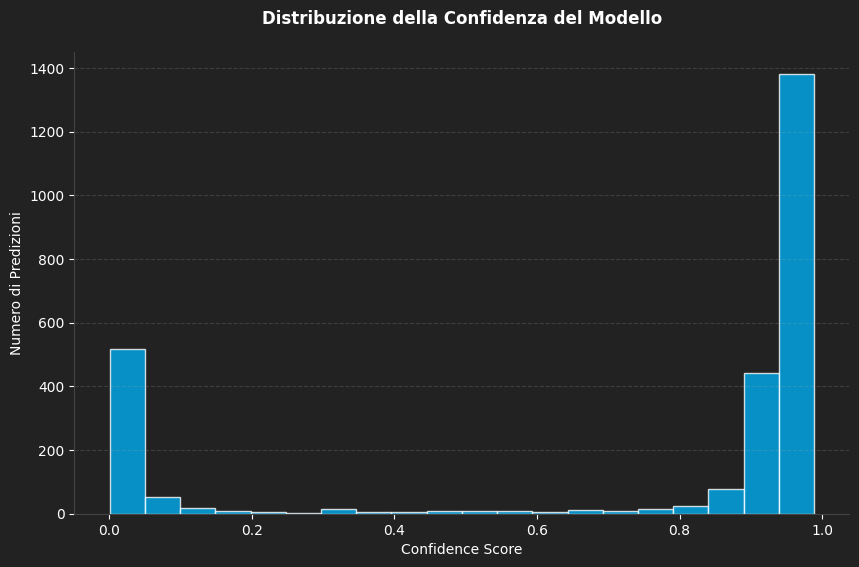

--- RIEPILOGO CONFIDENZA ---
Confidenza Media: 0.7212
Confidenza Massima: 0.9888
Predizioni sopra il 90%: 1772
---------------------------


In [9]:
import json
import numpy as np
import matplotlib.pyplot as plt

PRED_JSON = "./268986.json"  
bg_color = "#222222"   
color_main = "#00adef" 

def analizza_confidenza():
    with open(PRED_JSON, 'r') as f:
        preds = json.load(f)

    
    scores = np.array([p['score'] for p in preds])
    
    
    y_true = np.array([1 if p['score'] > 0.3 else 0 for p in preds]) 

    
    fig, ax = plt.subplots(figsize=(10, 6), facecolor=bg_color)
    ax.set_facecolor(bg_color)
    
    plt.hist(scores, bins=20, color=color_main, edgecolor='white', alpha=0.8)
    
    plt.title("Distribuzione della Confidenza del Modello", color='white', pad=20, fontweight='bold')
    plt.xlabel("Confidence Score", color='white')
    plt.ylabel("Numero di Predizioni", color='white')
    
    ax.tick_params(axis='both', colors='white')
    ax.spines['bottom'].set_color('#444444')
    ax.spines['left'].set_color('#444444')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.grid(axis='y', linestyle='--', alpha=0.2)
    plt.savefig("confidence_hist.png", transparent=True)
    plt.show()

    
    avg_conf = np.mean(scores)
    max_conf = np.max(scores)
    
    print(f"--- RIEPILOGO CONFIDENZA ---")
    print(f"Confidenza Media: {avg_conf:.4f}")
    print(f"Confidenza Massima: {max_conf:.4f}")
    print(f"Predizioni sopra il 90%: {np.sum(scores > 0.9)}")
    print(f"---------------------------")
if __name__ == "__main__":
    analizza_confidenza()